In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import pyod

warnings.filterwarnings('ignore')
plt.rcParams["figure.figsize"] = [16, 3]

In [2]:
file = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch8/nyc_taxi.csv')
nyc_taxi = pd.read_csv(file, index_col='timestamp', parse_dates=True)
nyc_taxi.index.freq = '30T'

In [3]:
nyc_dates = ["2014-11-01", "2014-11-27", "2014-12-25", "2015-01-01", "2015-01-27"]

In [4]:
def plot_outliers(outliers, data, method='KNN', halignment = 'right', valignment = 'top', labels=False):
    ax = data.plot(alpha=0.6)
    if labels:
        for i in outliers['value'].items():
            plt.plot(i[0], i[1], 'v', markersize=8, markerfacecolor='none', markeredgecolor='k')
            plt.text(i[0], i[1]-(i[1]*0.04), f'{i[0].strftime("%m/%d")}', horizontalalignment=halignment, verticalalignment=valignment)
    else:
        data.loc[outliers.index].plot(ax=ax, style='rX', markersize=9)
        
    plt.title(f'NYC Taxi - {method}')
    plt.xlabel('date'); plt.ylabel('# of passengers')
    plt.legend(['nyc taxi','outliers'])
    plt.show()

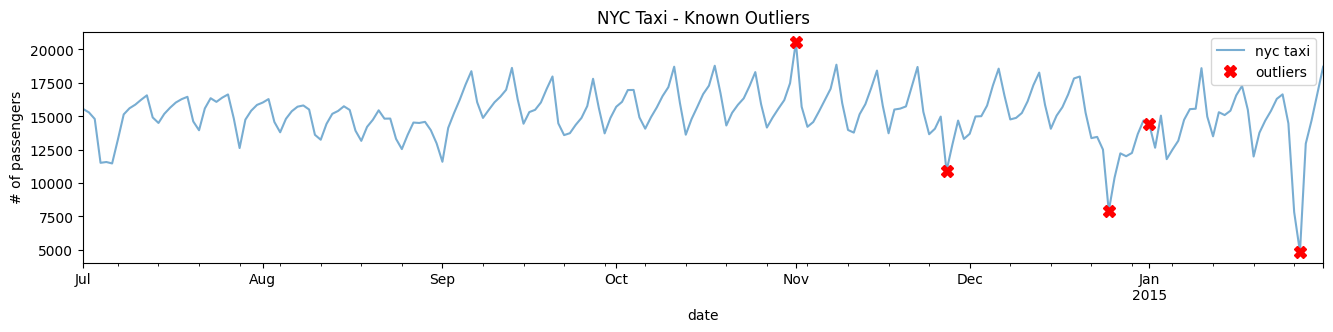

In [5]:
tx = nyc_taxi.resample('D').mean()
known_outliers = tx.loc[nyc_dates]
plot_outliers(known_outliers, tx, 'Known Outliers')

### 1. Detecting outliers using KNN

In [6]:
from pyod.models.knn import KNN

You should be familiar with a few parameters to control the algorithm's behavior. The first parameter is ***contamination***, a numeric (float) value representing the dataset's fraction of outliers. This is a common parameter across all the different classes (algorithms) in PyOD. For example, a contamination value of 0.1 indicates that you expect 10% of the data to be outliers. The default value is ***contamination***=0.1. The contamination value can range from 0 to 0.5 (or 50%). You will need to experiment with the contamination value, since the value influences the scoring threshold used to determine potential outliers, and how many of these potential outliers are to be returned. You will learn more about this in the How it works... section of this chapter.

For example, if you suspect the proportion of outliers in your data at 3%, then you can use that as the contamination value. You could experiment with different contamination values, inspect the results, and determine how to adjust the contamination level. We already know that there are 5 known outliers out of the 215
observations (around 2.3%), and in this recipe, you will use 0.03 (or 3%). 

The second parameter, specific to KNN, is method, which defaults to ***method***='largest'. In this recipe, you will change it to the mean (the average of all k neighbor distances). The third parameter, also specific to KNN, is metric, which tells the algorithm how to compute the distances. The default is the minkowski distance but it can take any distance metrics from scikit-learn or the SciPy library. Finally, you need to provide the number of neighbors, which defaults to ***n_neighbors***=5. Ideally, you will want to run for different KNN models with varying values of k and compare the results to determine the optimal number of neighbors.

In [7]:
knn = KNN(contamination=0.03, method='mean', n_neighbors=5)
knn.fit(tx)

KNN(algorithm='auto', contamination=0.03, leaf_size=30, method='mean',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0)

In [8]:
predicted = pd.Series(knn.predict(tx), index=tx.index)
print('Number of outliers = ', predicted.sum())

Number of outliers =  6


In [9]:
outliers = predicted[predicted == 1]
outliers = tx.loc[outliers.index]
outliers

,value
timestamp,
2014-11-01,20553.500000
2014-11-27,10899.666667
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-26,7818.979167
2015-01-27,4834.541667


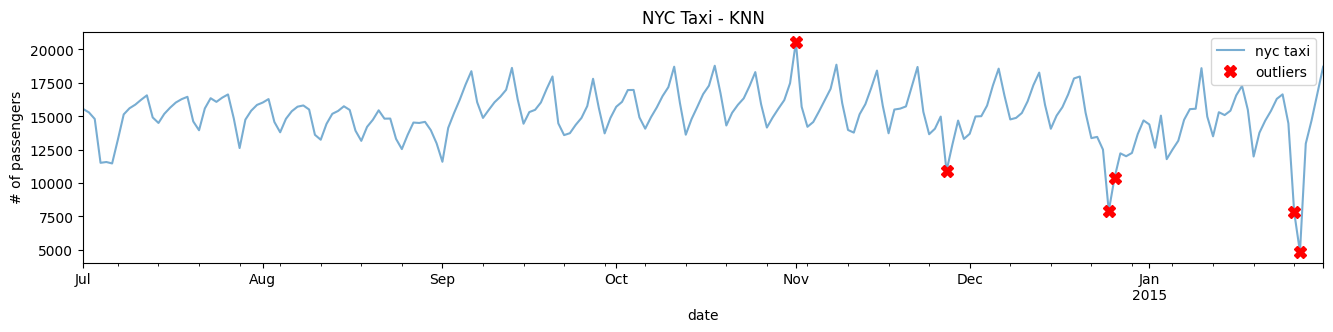

In [10]:
plot_outliers(outliers, tx, 'KNN')

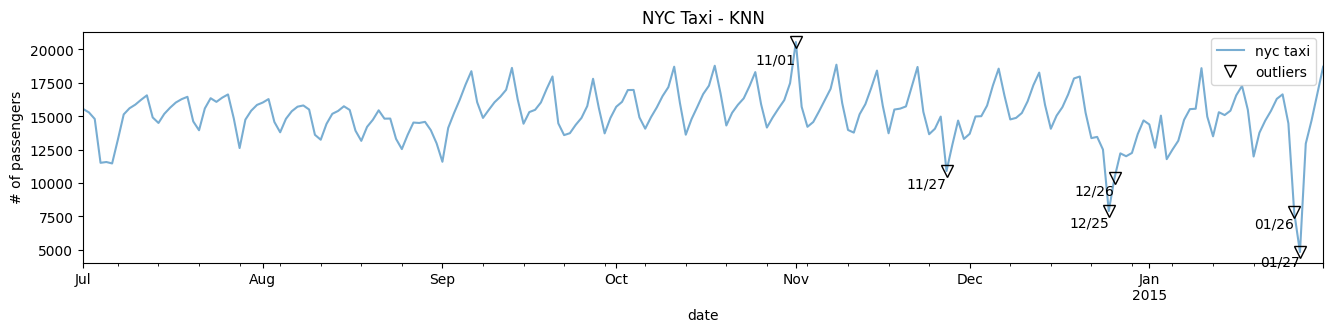

In [11]:
plot_outliers(outliers, tx, 'KNN', labels=True)

In [12]:
knn_scores = knn.decision_scores_
knn_scores

array([  26.52083333,   26.79166667,   20.36666667,  186.20833333,
        162.        ,  224.20833333,   59.58333333,   45.725     ,
         21.7625    ,   22.7       ,   23.54583333,   42.65416667,
         19.11666667,   28.675     ,   38.27916667,   37.01666667,
         17.94583333,   28.5       ,   64.75416667,   46.55833333,
         57.49166667,   16.4875    ,   47.00833333,   29.125     ,
         64.05833333,   29.75      ,   18.81666667,  112.5625    ,
         26.49583333,   19.38333333,   25.30833333,   20.3125    ,
         30.4125    ,   34.57083333,   56.29583333,   15.48333333,
         28.98333333,   15.01666667,   33.33333333,   19.04583333,
         26.80833333,   61.1625    ,   40.45833333,   38.27916667,
         19.58333333,   26.05      ,   15.80416667,   78.03333333,
         98.82916667,   75.04166667,   27.57916667,   31.25416667,
         15.48333333,   18.36666667,   61.95833333,  107.92083333,
         29.7       ,   40.525     ,   28.575     ,   37.02916

In [13]:
knn_scores_df = (pd.DataFrame(knn_scores, index=tx.index, columns=['score']))
knn_scores_df

,score
timestamp,
2014-07-01,26.520833
2014-07-02,26.791667
2014-07-03,20.366667
2014-07-04,186.208333
2014-07-05,162.000000
...,...
2015-01-27,4862.058333
2015-01-28,166.979167
2015-01-29,24.816667


In [14]:
knn.threshold_

225.0179166666657

This is the value used to filter out the significant outliers. Here is an example of how you reproduce that.

In [15]:
knn_scores_df[knn_scores_df['score'] >= knn.threshold_].sort_values('score', ascending=False)

,score
timestamp,
2015-01-27,4862.058333
2015-01-26,2474.508333
2014-12-25,2441.250000
2014-11-01,1806.850000
2014-12-26,1009.616667
2014-11-27,608.250000
2014-09-27,225.604167


Notice the last observation on 2014-09-27 is slightly above the threshold, but it was not returned when you used the predict method. If you use the contamination threshold, you can get a better cutoff:

In [16]:
n = int(len(tx)*0.03)
knn_scores_df.nlargest(n, 'score')

,score
timestamp,
2015-01-27,4862.058333
2015-01-26,2474.508333
2014-12-25,2441.250000
2014-11-01,1806.850000
2014-12-26,1009.616667
2014-11-27,608.250000


Another helpful method is predict_proba, which returns the probability of being normal and the probability of being abnormal for each observation. PyOD provides two methods for determining these percentages: linear or unify. The two methods scale the outlier scores before calculating the probabilities. For example, in the case of linear,
the implementation uses MinMaxScaler from scikit-learn to scale the scores before calculating the probabilities. The unify method uses the z-score (standardization) and the Gaussian error function (erf) from the SciPy library (scipy.special.erf).

You can compare the two approaches. First, start using the linear method to calculate the prediction probability, you can use the following:

In [17]:
knn_proba = knn.predict_proba(tx, method='linear')
knn_proba_df = (pd.DataFrame(np.round(knn_proba * 100, 3), index=tx.index, columns=['Proba_Normal', 'Proba_Anomaly']))
knn_proba_df.nlargest(n, 'Proba_Anomaly')

,Proba_Normal,Proba_Anomaly
timestamp,,
2015-01-27,27.337,72.663
2015-01-26,64.256,35.744
2014-12-25,64.599,35.401
2014-11-01,70.682,29.318
2014-12-26,84.341,15.659
2014-11-27,90.548,9.452


For the unify method, you can just update method='unify'.

To save any PyOD model, you can use the joblib Python library.

In [18]:
from joblib import dump, load

# save the knn model
dump(knn, 'knn_outliers.joblib')

# load the knn model
knn = load('knn_outliers.joblib')

In [19]:
def knn_anomaly(df, method='mean', contamination=0.05, k=5):
    knn = KNN(contamination=contamination, method=method, n_neighbors=5)
    knn.fit(df)
    decision_score = pd.DataFrame(knn.decision_scores_,
    index=df.index, columns=['score'])
    n = int(len(df)*contamination)
    outliers = decision_score.nlargest(n, 'score')
    
    return outliers, knn.threshold_

In [20]:
for method in ['mean', 'median', 'largest']:
    o, t = knn_anomaly(tx, method=method)
    print(f'Method= {method}, Threshold= {t}')
    print(o)

Method= mean, Threshold= 220.32916666666603
                  score
timestamp              
2015-01-27  4862.058333
2015-01-26  2474.508333
2014-12-25  2441.250000
2014-11-01  1806.850000
2014-12-26  1009.616667
2014-11-27   608.250000
2014-09-27   225.604167
2014-07-06   224.208333
2014-12-28   223.562500
2015-01-19   223.562500
Method= median, Threshold= 211.64999999999995
                  score
timestamp              
2015-01-27  5563.416667
2014-12-25  2997.541667
2015-01-26  2984.437500
2014-11-01  1847.083333
2014-12-26  1113.812500
2014-11-27   612.104167
2014-12-29   251.520833
2014-12-27   238.062500
2015-01-19   238.062500
2014-12-28   219.145833
Method= largest, Threshold= 411.85624999999993
                  score
timestamp              
2015-01-27  6629.729167
2015-01-26  3645.291667
2014-12-25  3562.145833
2014-11-01  1865.437500
2014-12-26  1191.916667
2014-11-27   690.208333
2014-07-06   518.583333
2014-07-04   471.083333
2014-12-19   436.604167
2014-09-27   431.750000

### 2. Detecting outliers using LOF

In [21]:
from pyod.models.lof import LOF

You should be familiar with a few parameters to control the algorithm's behavior. The first parameter is contamination, a numeric (float) value representing the dataset's fraction of outliers. For example, a value of 0.1 indicates that you expect 10% of the data to be outliers. The default value is contamination=0.1. In this
recipe, you will use 0.03 (3%).

The second parameter is the number of neighbors, which defaults to n_neighbors=5, similar to the KNN algorithm. Ideally, you will want to run different models with varying values of k (n_neighbors) and compare the
results to determine the optimal number of neighbors. Lastly, the metric parameter specifies which metric to use to calculate the distance. This can be any distance metrics from the scikit-learn or SciPy libraries (for example, Euclidean or Manhattan distance). The default value is the Minkowski distance with metric='minkowski'. Since the Minkowski distance is a generalization for both the Euclidean ( 𝑙𝑙2 ) and Manhattan distances ( 𝑙𝑙1), you will notice a p parameter. By default, p=2 indicates Euclidean distance, while a value of p=1 indicates Manhattan distance.

In [22]:
lof = LOF(contamination=0.03, n_neighbors=5)
lof.fit(tx)

LOF(algorithm='auto', contamination=0.03, leaf_size=30, metric='minkowski',
  metric_params=None, n_jobs=1, n_neighbors=5, novelty=True, p=2)

The predict method will output either 1 or 0 for each data point. A value of 1 indicates an outlier. Store the results in a pandas Series

In [23]:
predicted = pd.Series(lof.predict(tx), index=tx.index)
print('Number of outliers = ', predicted.sum())

Number of outliers =  6


Filter the predicted Series to only show the outlier values.

In [24]:
outliers = predicted[predicted == 1]
outliers = tx.loc[outliers.index]
outliers

,value
timestamp,
2014-10-31,17473.354167
2014-11-01,20553.500000
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-26,7818.979167
2015-01-27,4834.541667


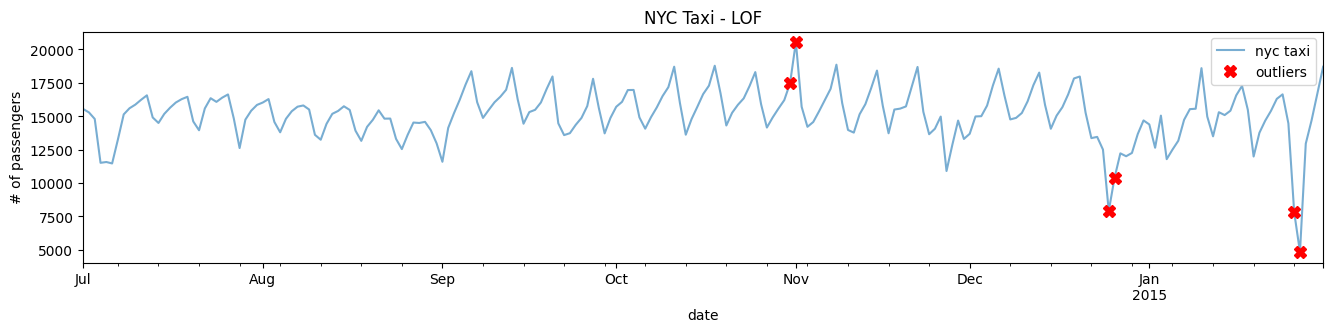

In [25]:
plot_outliers(outliers, tx, 'LOF')

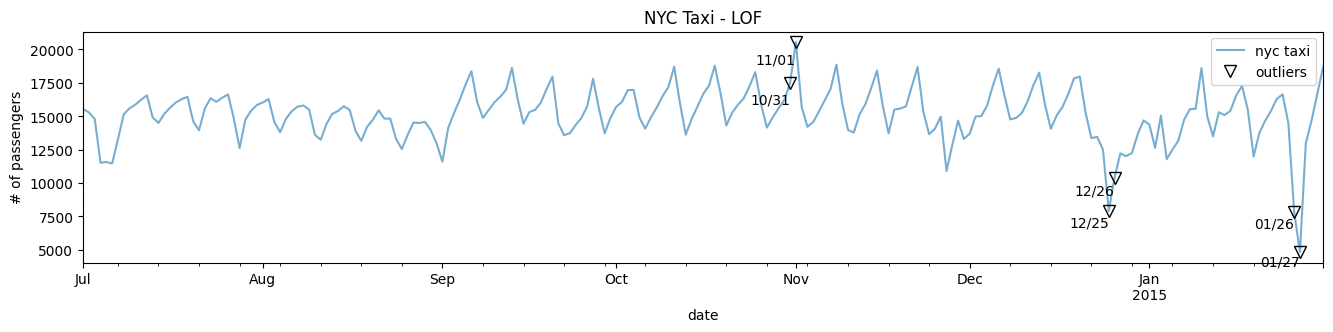

In [26]:
plot_outliers(outliers, tx, 'LOF', labels=True)

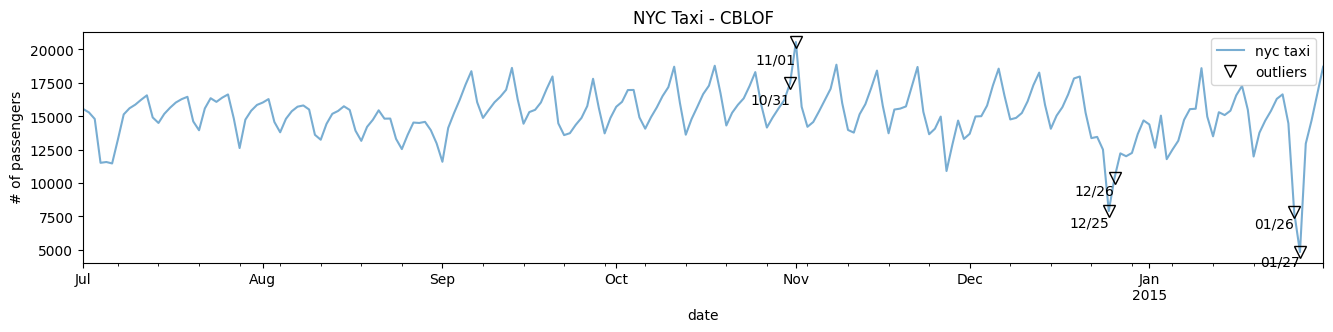

In [28]:
from pyod.models.cblof import CBLOF

cblof = CBLOF(n_clusters=4, contamination=0.03)
cblof.fit(tx)

predicted = pd.Series(lof.predict(tx), index=tx.index)

outliers = predicted[predicted == 1]
outliers = tx.loc[outliers.index]

plot_outliers(outliers, tx, 'CBLOF', labels=True)

### 3. Detecting outliers using iForest

iForest has similarities with another popular algorithm known as Random Forests. Random Forests is a tree-based supervised learning algorithm. In supervised learning, you have existing labels (classification) or values (regression) representing the target variable. This is how the algorithm learns (it is supervised).

The name forest stems from the underlying mechanism of how the algorithm works. For example, in classification, the algorithm randomly samples the data to build multiple weak classifiers (smaller decision trees) that collectively make a prediction. In the end, you get a forest of smaller trees (models). This technique outperforms a single complex classifier that may overfit the data. Ensemble learning is the concept of multiple weak learners
collaborating to produce an optimal solution.

iForest, also an ensemble learning method, is the unsupervised learning approach to Random Forests. The iForest algorithm isolates anomalies by randomly partitioning (splitting) a dataset into multiple partitions. This is performed recursively until all data points belong to a partition. The number of partitions required to isolate an anomaly is typically smaller than the number of partitions needed to isolate a regular point. The idea is that an anomaly data point is further from other points and thus easier to separate (isolate).

In contrast, a normal data point is probably clustered closer to the larger set and, therefore, will require more partitions (splits) to isolate that point. Hence the name, isolation forest, since it identifies outliers through isolation. Once all the points are isolated, the algorithm will create an outlier score. You can think of these splits as creating a decision tree path. The shorter the path length to a point, the higher the chances of an anomaly.

In [29]:
from pyod.models.iforest import IForest

There are a few parameters that you should be familiar with to control the algorithm's behavior. The first parameter is contamination. The default value is contamination=0.1 but in this recipe, you will use 0.03 (3%).

The second parameter is n_estimators, which defaults to n_estimators=100. This is the number of random trees generated. Depending on the complexity of your data, you may want to increase this value to a higher range,
such as 500 or more. Start with the default smaller value to understand how the baseline model works—finally, random_state defaults to None. Since the iForest algorithm randomly generates partitions for the data, it is good to set a value to ensure that your work is reproducible. This way, you can get consistent results back when you rerun the code. Of course, this could be any integer value.

In [30]:
iforest = IForest(contamination=0.03, n_estimators=100, random_state=0)
iforest.fit(tx)

IForest(behaviour='old', bootstrap=False, contamination=0.03,
    max_features=1.0, max_samples='auto', n_estimators=100, n_jobs=1,
    random_state=0, verbose=0)

In [31]:
predicted = pd.Series(iforest.predict(tx), index=tx.index)
print('Number of outliers = ', predicted.sum())

Number of outliers =  7


In [32]:
outliers = predicted[predicted == 1]
outliers = tx.loc[outliers.index]
outliers

,value
timestamp,
2014-11-01,20553.500000
2014-11-08,18857.333333
2014-11-27,10899.666667
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-26,7818.979167
2015-01-27,4834.541667


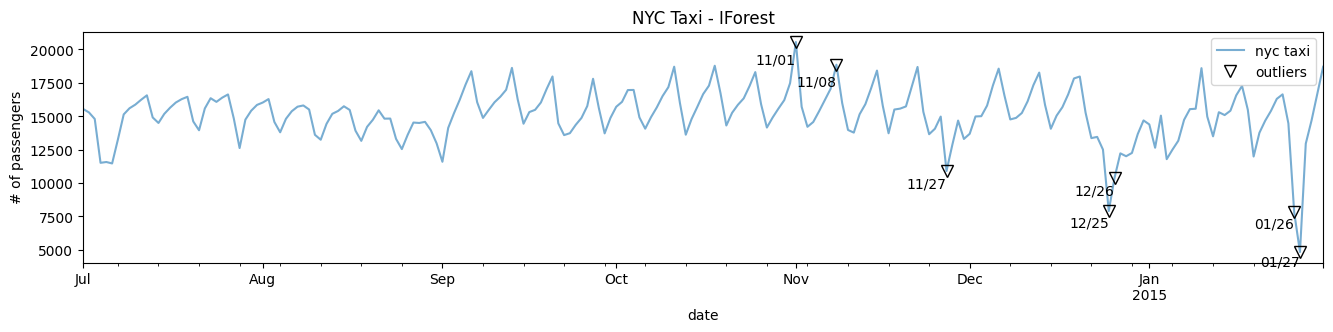

In [33]:
plot_outliers(outliers=outliers, data=tx, method='IForest', labels=True)

The previous code should produce a similar plot with additional text labels.

In [34]:
from sklearn.ensemble import IsolationForest

sk_iforest = IsolationForest(contamination=0.03)
sk_prediction = pd.Series(sk_iforest.fit_predict(tx), index=tx.index)
sk_outliers = sk_prediction[sk_prediction == -1]
sk_outliers = tx.loc[sk_outliers.index]
sk_outliers

,value
timestamp,
2014-11-01,20553.500000
2014-11-08,18857.333333
2014-11-27,10899.666667
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-26,7818.979167
2015-01-27,4834.541667


### 4. Detecting outliers using One-Class Support Vector Machine (OCSVM)

Support Vector Machine (SVM) is a popular supervised machine learning algorithm that is mainly known for classification but can also be used for regression. The popularity of SVM comes from the use of kernel functions (sometimes referred to as the kernel trick), such as linear, polynomial, Radius-Based Function (RBF), and the sigmoid function. 

In addition to classification and regression, SVM can also be used for outlier detection in an unsupervised manner, similar to KNN, which is mostly known as a supervised machine learning technique but was used in an unsupervised manner for outlier detection, as seen in the Outlier detection using KNN recipe.

In [35]:
from pyod.models.ocsvm import OCSVM

There are a few parameters that you should be familiar with to control the algorithm's behavior. The first parameter is contamination. The default value is contamination=0.1 and in this recipe, you will use 0.03 (3%).
The second parameter is kernel, which is set to rbf, which you will keep as is. Instantiate OCSVM by updating contamination=0.03 while keeping the rest of the parameters with the default values. Then, train (fit) the model.

In [36]:
ocsvm = OCSVM(contamination=0.03, kernel='rbf')
ocsvm.fit(tx)

OCSVM(cache_size=200, coef0=0.0, contamination=0.03, degree=3, gamma='auto',
   kernel='rbf', max_iter=-1, nu=0.5, shrinking=True, tol=0.001,
   verbose=False)

In [37]:
predicted = pd.Series(ocsvm.predict(tx), index=tx.index)
print('Number of outliers = ', predicted.sum())

Number of outliers =  5


In [38]:
outliers = predicted[predicted == 1]
outliers = tx.loc[outliers.index]
outliers

,value
timestamp,
2014-08-09,15499.708333
2014-11-18,15499.437500
2014-11-27,10899.666667
2014-12-24,12502.000000
2015-01-05,12502.750000


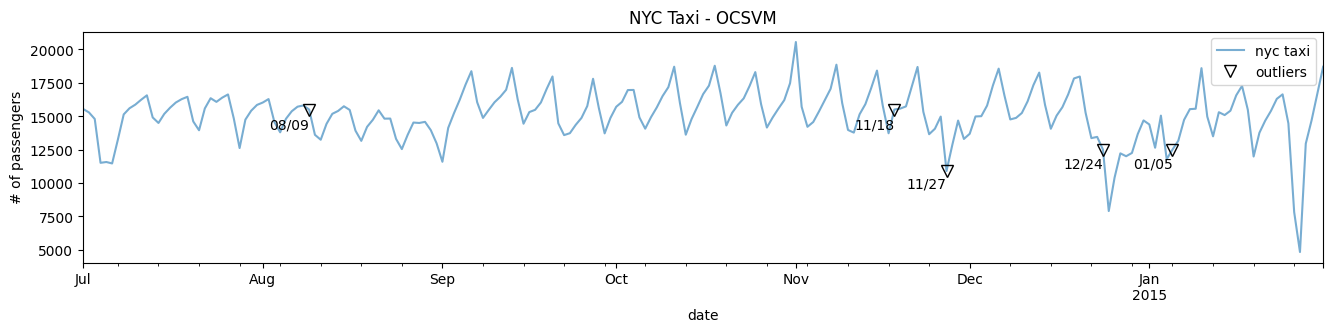

In [39]:
plot_outliers(outliers, tx, 'OCSVM', labels=True)

In [40]:
from pyod.utils.utility import standardizer

scaled = standardizer(tx)
predicted = pd.Series(ocsvm.fit_predict(scaled), index=tx.index)

outliers = predicted[predicted == 1]
outliers = tx.loc[outliers.index]
outliers

,value
timestamp,
2014-07-06,11464.270833
2014-11-01,20553.500000
2014-11-27,10899.666667
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-26,7818.979167
2015-01-27,4834.541667


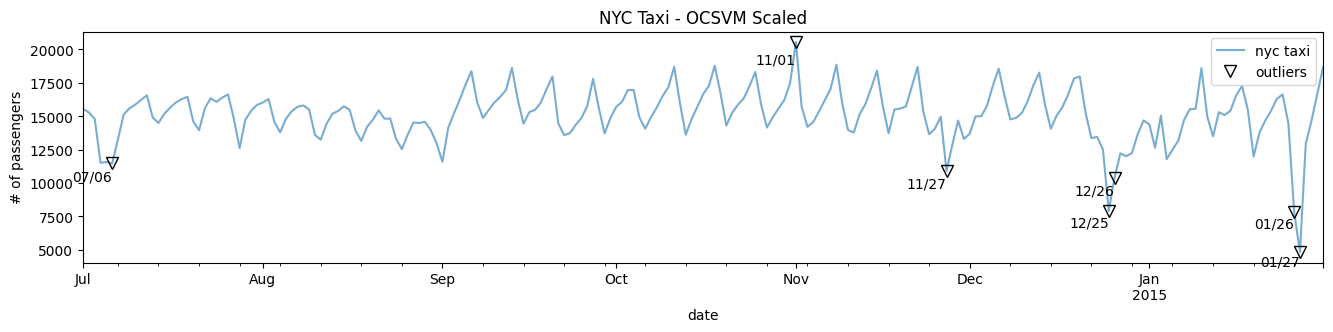

In [41]:
plot_outliers(outliers, tx, 'OCSVM Scaled', labels=True)

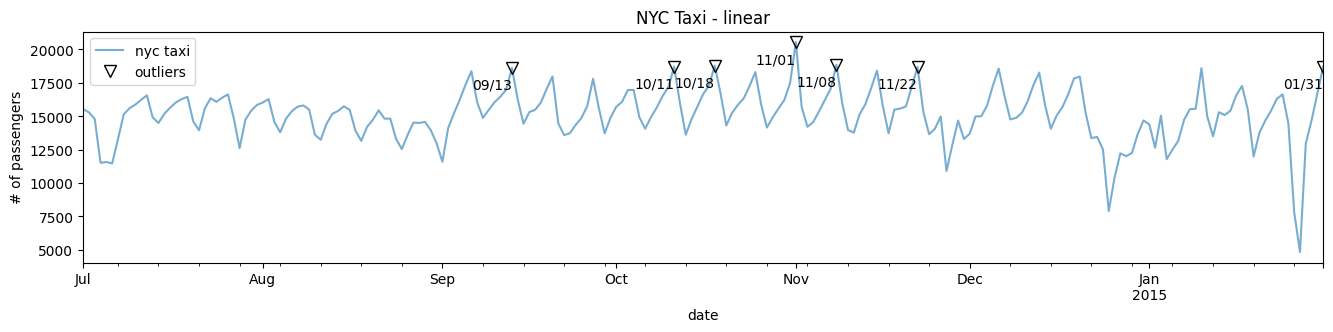

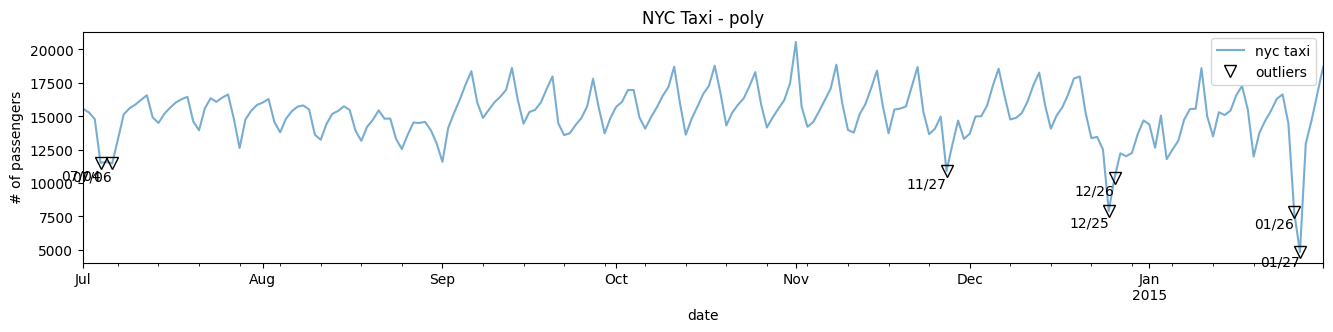

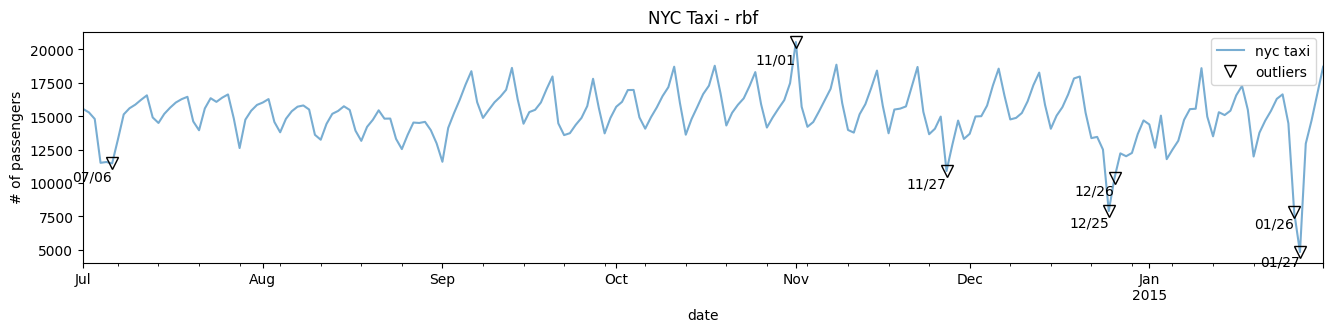

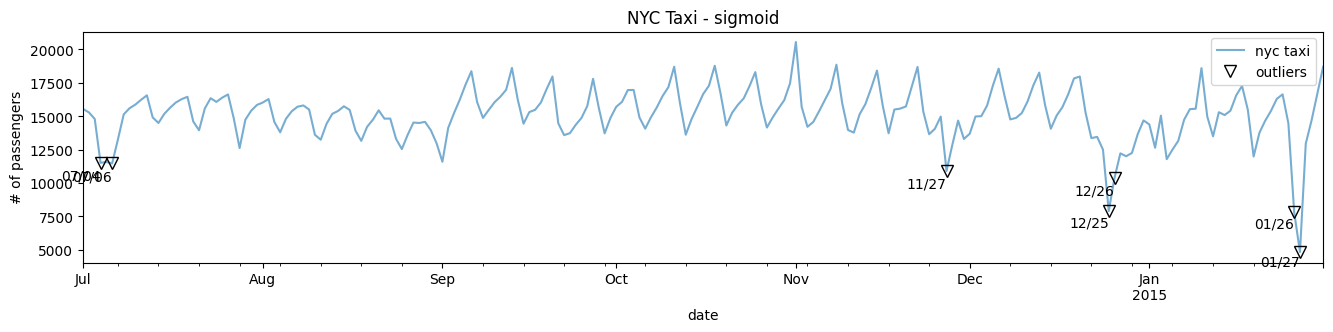

In [42]:
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    ocsvm = OCSVM(contamination=0.03, kernel=kernel)
    predict = pd.Series(ocsvm.fit_predict(scaled), index=tx.index, name=kernel)

    outliers = predict[predict == 1]
    outliers = tx.loc[outliers.index]
    
    plot_outliers(outliers, tx, kernel, labels=True)

### 5. Detecting outliers using COPOD

COPOD falls under probabilistic models and is labeled as a parameter-free algorithm. The only parameter it takes is the contamination factor, which defaults to 0.1. The COPOD algorithm is inspired by statistical methods, making it a fast and highly interpretable model. The algorithm is based on copula, a function generally used to model dependence between independent random variables that are not necessarily normally distributed. In time series forecasting, copulas have been used in univariate and multivariate forecasting, which is popular in financial risk modeling. The term copula stems from the copula function joining (coupling) univariate marginal distributions to form a uniform multivariate distribution function.

In [43]:
from pyod.models.copod import COPOD

The only parameter you need to consider is contamination. Generally, think of this parameter (used in all the outlier detection implementations) as a threshold to control the model's sensitivity and minimize the false positives. Since it is a parameter you control, ideally, you want to run several models to experiment with the ideal threshold rate that works for your use cases.

For more insight into decision_scores_, threshold_, or predict_proba, please review the first recipe, Detecting outliers using KNN.

In [44]:
copod = COPOD(contamination=0.03)
copod.fit(tx)

COPOD(contamination=0.03, n_jobs=1)

In [45]:
predicted = pd.Series(copod.predict(tx), index=tx.index)
print('Number of outliers = ', predicted.sum())

Number of outliers =  7


In [46]:
outliers = predicted[predicted == 1]
outliers = tx.loc[outliers.index]
outliers

,value
timestamp,
2014-07-04,11511.770833
2014-07-06,11464.270833
2014-11-27,10899.666667
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-26,7818.979167
2015-01-27,4834.541667


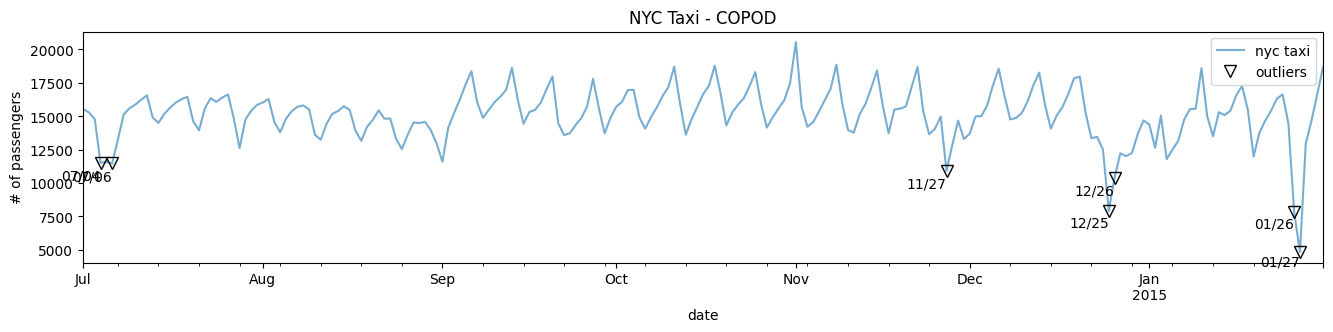

In [47]:
plot_outliers(outliers, tx, 'COPOD', labels=True)

In [48]:
from pyod.models.mad import MAD

mad = MAD(threshold=3)
predicted = pd.Series(mad.fit_predict(tx), index=tx.index)

outliers = predicted[predicted == 1]
outliers = tx.loc[outliers.index]

outliers

,value
timestamp,
2014-11-01,20553.500000
2014-11-27,10899.666667
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-26,7818.979167
2015-01-27,4834.541667


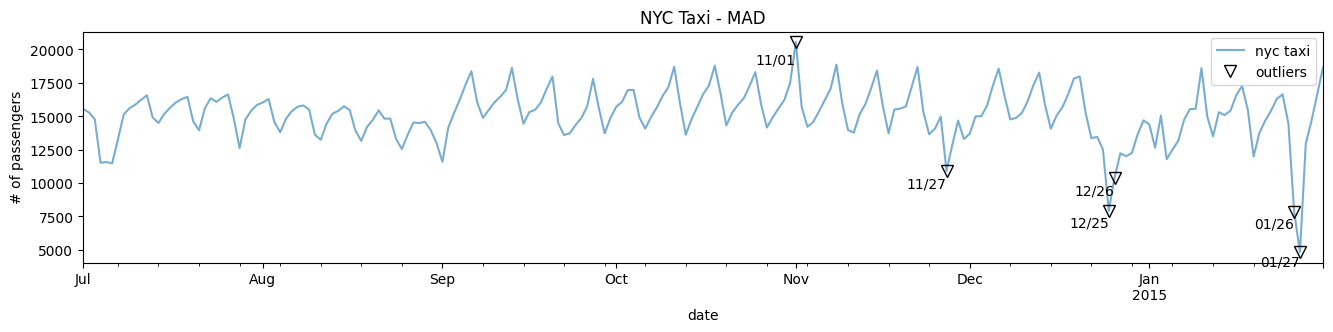

In [49]:
plot_outliers(outliers, tx, 'MAD', labels=True)

### 6. Detecting outliers with PyCaret

In [ ]:
from pycaret.anomaly import *

setup = setup(tx, session_id = 1, normalize=True)

In [ ]:
models()

In [ ]:
list_of_models = models().index.tolist()[0:8]
list_of_models

In [ ]:
results = {}
for model in list_of_models:
    cols = ['value', 'Anomaly_Score']
    outlier_model = create_model(model, fraction=0.03)
    print(outlier_model)

    outliers = predict_model(outlier_model, data=tx)
    outliers = outliers[outliers['Anomaly'] == 1][cols]
    outliers.sort_values('Anomaly_Score', ascending=False, inplace=True)
    results[model] = {'data': outliers, 'model': outlier_model}

In [ ]:
for model in results:
    print(f'Model: {model}')
    print(results[model]['data'], '\n')